In [ ]:
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
from skl2onnx import to_onnx
import onnx, joblib
from sklearn.preprocessing import FunctionTransformer


#Load dataset
BRFSS=Path("../data/brfss/LLCP2023.XPT")
raw=pd.read_sas(BRFSS,format="xport",encoding="utf-8")
raw.columns=raw.columns.str.upper()
print(f"Loaded BRFSS 2023:{raw.shape[0]:,} rows,{raw.shape[1]:,} cols")

def get_first(df, cols):
    for c in cols:
        if c in df.columns:
            return df[c]
    return pd.Series([np.nan]*len(df))

df=pd.DataFrame({
    "AGE": get_first(raw,["_AGE80","AGE"]),
    "SEX": get_first(raw,["_SEX","SEXVAR","SEX"]),
    "BMI_X100": get_first(raw,["_BMI5"]),
    "PA_ANY": get_first(raw,["_TOTINDA"]),
    "SMOKE_FLAG": get_first(raw,["_RFSMOK3"]),
    "HTN_RAW": get_first(raw,["BPHIGH6"]),
    "STRESS_RAW": get_first(raw,["SDHSTRE1","MENTHLTH"]),
    "HTN_DER": get_first(raw,["_RFHYPE6"]),
    "PA_INDEX": get_first(raw,["_PAINDX3"]),
    "HEART_RAW": get_first(raw,["CVDCRHD4","CVDCRHD3","CVDINFR4"])
})

df=df.replace({77:np.nan,88:np.nan,99:np.nan})
df["AGE"]=pd.to_numeric(df["AGE"],errors="coerce")
df["BMI"]=pd.to_numeric(df["BMI_X100"],errors="coerce")/100.0
df["SEX_MALE"]=(df["SEX"].astype(str).str.strip().isin(["1"])).astype(int)

#Physical activity:1=active,2=inactive
df["PA_ANY"]=df["PA_ANY"].map({1:1,2:0})

#smoking mapping (1=No:0,2=Yes:1)
df["SMOKING_IDX"]=df["SMOKE_FLAG"].map({1:0,2:1})

#Hypertension:0=no HTN,1=has HTN
htn="HTN_DER" if df["HTN_DER"].notna().any() else "HTN_RAW"
df["HTN_FLAG"]=df[htn].map({1:0,2:1})

#Stress:use numeric days(0–30)
df["STRESS_RAW"]=pd.to_numeric(df["STRESS_RAW"],errors="coerce")
df.loc[df["STRESS_RAW"].isin([7,9,77,99]),"STRESS_RAW"] = np.nan
df["STRESS_SCORE"]=df["STRESS_RAW"]

df["PA_INDEX"]=pd.to_numeric(df["PA_INDEX"],errors="coerce")
df["STRESSxPA"]=df["STRESS_SCORE"]*(1-df["PA_ANY"])

#Heart flag:1=yes,0=no
df["HEART_FLAG"]=df["HEART_RAW"].map({1:1,2:0})

#Alcohol flag: 1=no,2=heavy drinker
df["ALC_FLAG"]=get_first(raw,["_RFDRHV8"])
#Chol flag: 1=no high chol,2=yes high chol
df["CHOL_FLAG"]=get_first(raw,["_RFCHOL3"])

#Chol screening flag: 1=checked recently,2/3=no/never checked
df["CHOL_SCREEN"]=get_first(raw,["_CHOLCH3"])

for col in ["ALC_FLAG","CHOL_FLAG","CHOL_SCREEN"]:
    df[col]=pd.to_numeric(df[col],errors="coerce")

#Alcohol flag: 0=no risk,1=risk
df["ALC_FLAG"]=df["ALC_FLAG"].map({1:0,2:1})

#Chol flag: 0=no risk,1=risk
df["CHOL_FLAG"]=df["CHOL_FLAG"].map({1:0,2:1})

#Chol screen flag: 0=recent check,1=not checked
df["CHOL_SCREEN"]=df["CHOL_SCREEN"].map({1:0,2:1,3:1})

#Health Activity related
df["ACTIVITY_TYPE"]=get_first(raw,["EXRACT12"])
df["ACTIVITY_TYPE"]=pd.to_numeric(df["ACTIVITY_TYPE"],errors="coerce")

#Normalize EXRACT12 activity into numeric set
map1={1:1,2:2,3:3,4:4,10:5,11:6}
df["ACTIVITY_TYPE_CODE"]=df["ACTIVITY_TYPE"].map(map1)
df["EXEROFT1"]=pd.to_numeric(get_first(raw,["EXEROFT1"]),errors="coerce")
df["EXER_FREQ_WK"]=np.where(df["EXEROFT1"].between(101,199),df["EXEROFT1"]-100,np.where(df["EXEROFT1"].between(201,299),(df["EXEROFT1"]-200)/(30/7),np.nan))
df["STRENGTH"]=pd.to_numeric(get_first(raw,["STRENGTH"]),errors="coerce")
df["STRENGTH_FREQ"]=np.where(df["STRENGTH"].between(101,199), df["STRENGTH"]-100,np.where(df["STRENGTH"].between(201,299),(df["STRENGTH"]-200)/(30/7),np.nan))

#Cap unrealistic frequencies to maximum 14 sessions/week
df["EXER_FREQ_WK"]=np.clip(df["EXER_FREQ_WK"],0,14)
df["STRENGTH_FREQ"]=np.clip(df["STRENGTH_FREQ"],0,14)

df["STRENGTH_FLAG"]=(df["STRENGTH_FREQ"]>=2).astype(int)
df["_HLTHPL1"]=pd.to_numeric(get_first(raw,["_HLTHPL1"]),errors="coerce")
df["INSURED_FLAG"]=df["_HLTHPL1"].map({1:1,2:0})

#Define feautures
numF=["AGE","BMI","PA_ANY","SMOKING_IDX","HTN_FLAG","STRESS_SCORE","PA_INDEX","STRESSxPA","ALC_FLAG","CHOL_FLAG","CHOL_SCREEN"]
catf=[]
numF+=["SEX_MALE"]
numF+=["EXER_FREQ_WK", "STRENGTH_FREQ", "INSURED_FLAG", "ACTIVITY_TYPE_CODE"]

#Ensure categorical are strings
#Fill empty with "missing"
for col in catf:
    df[col]=df[col].astype(str).fillna("missing")
df[numF]=df[numF].fillna(df[numF].median())
df=df.dropna(subset=numF + catf + ["HEART_FLAG"])
X=df[numF+catf]
y=df["HEART_FLAG"].astype(int)
print("Feature matrix shape:",X.shape)
print("Class distribution:\n",y.value_counts())

#Balance classes
dft=X.copy()
dft["HEART_FLAG"]=y
pos=dft[dft.HEART_FLAG==1]
neg=dft[dft.HEART_FLAG==0]
n_samples=min(len(pos), 8000)
up=resample(pos,replace=True,n_samples=n_samples,random_state=42)
down=resample(neg,replace=False,n_samples=n_samples*2,random_state=42)
dfb=pd.concat([up,down])
X=dfb.drop(columns=["HEART_FLAG"])
y=dfb["HEART_FLAG"]
print("Balanced class distribution:\n",y.value_counts())

#Build preprocessing
np1=Pipeline([("scale",StandardScaler())])
def fill_missing_str(X):
    return np.where(pd.isna(X), "missing", X)
cp1=Pipeline([("onehot",OneHotEncoder(handle_unknown="ignore"))])
preproc=ColumnTransformer([("num",np1,numF),("cat",cp1,catf)])

#Create ONNX safe RandomForest model
clf=Pipeline([("preproc",preproc),("rf",RandomForestClassifier(n_estimators=300,max_depth=10,class_weight="balanced",random_state=42))])

#train model
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
clf.fit(Xtr,ytr)
print("RandomForest model trained successfully")

#Evaluate model
pred=clf.predict(Xte)
prob=clf.predict_proba(Xte)[:,1]
auc=roc_auc_score(yte,prob)
print("\nROC–AUC:",round(auc,3))
print("\nClassification Report:\n",classification_report(yte,pred))
print("Confusion Matrix:\n",confusion_matrix(yte,pred))

✅ Loaded BRFSS 2023: 433,323 rows, 350 cols
✅ Feature matrix shape: (429092, 16)
Class distribution:
 HEART_FLAG
0    405638
1     23454
Name: count, dtype: int64
Balanced class distribution:
 HEART_FLAG
0    16000
1     8000
Name: count, dtype: int64
✅ RandomForest model trained successfully

🔹 ROC–AUC: 0.794

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.67      0.75      3200
           1       0.54      0.78      0.64      1600

    accuracy                           0.71      4800
   macro avg       0.70      0.73      0.70      4800
weighted avg       0.76      0.71      0.72      4800

🔹 Confusion Matrix:
 [[2150 1050]
 [ 348 1252]]


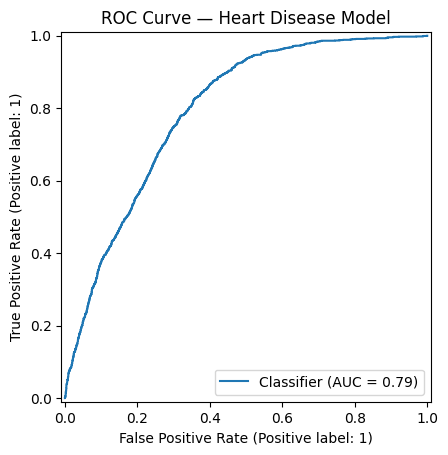

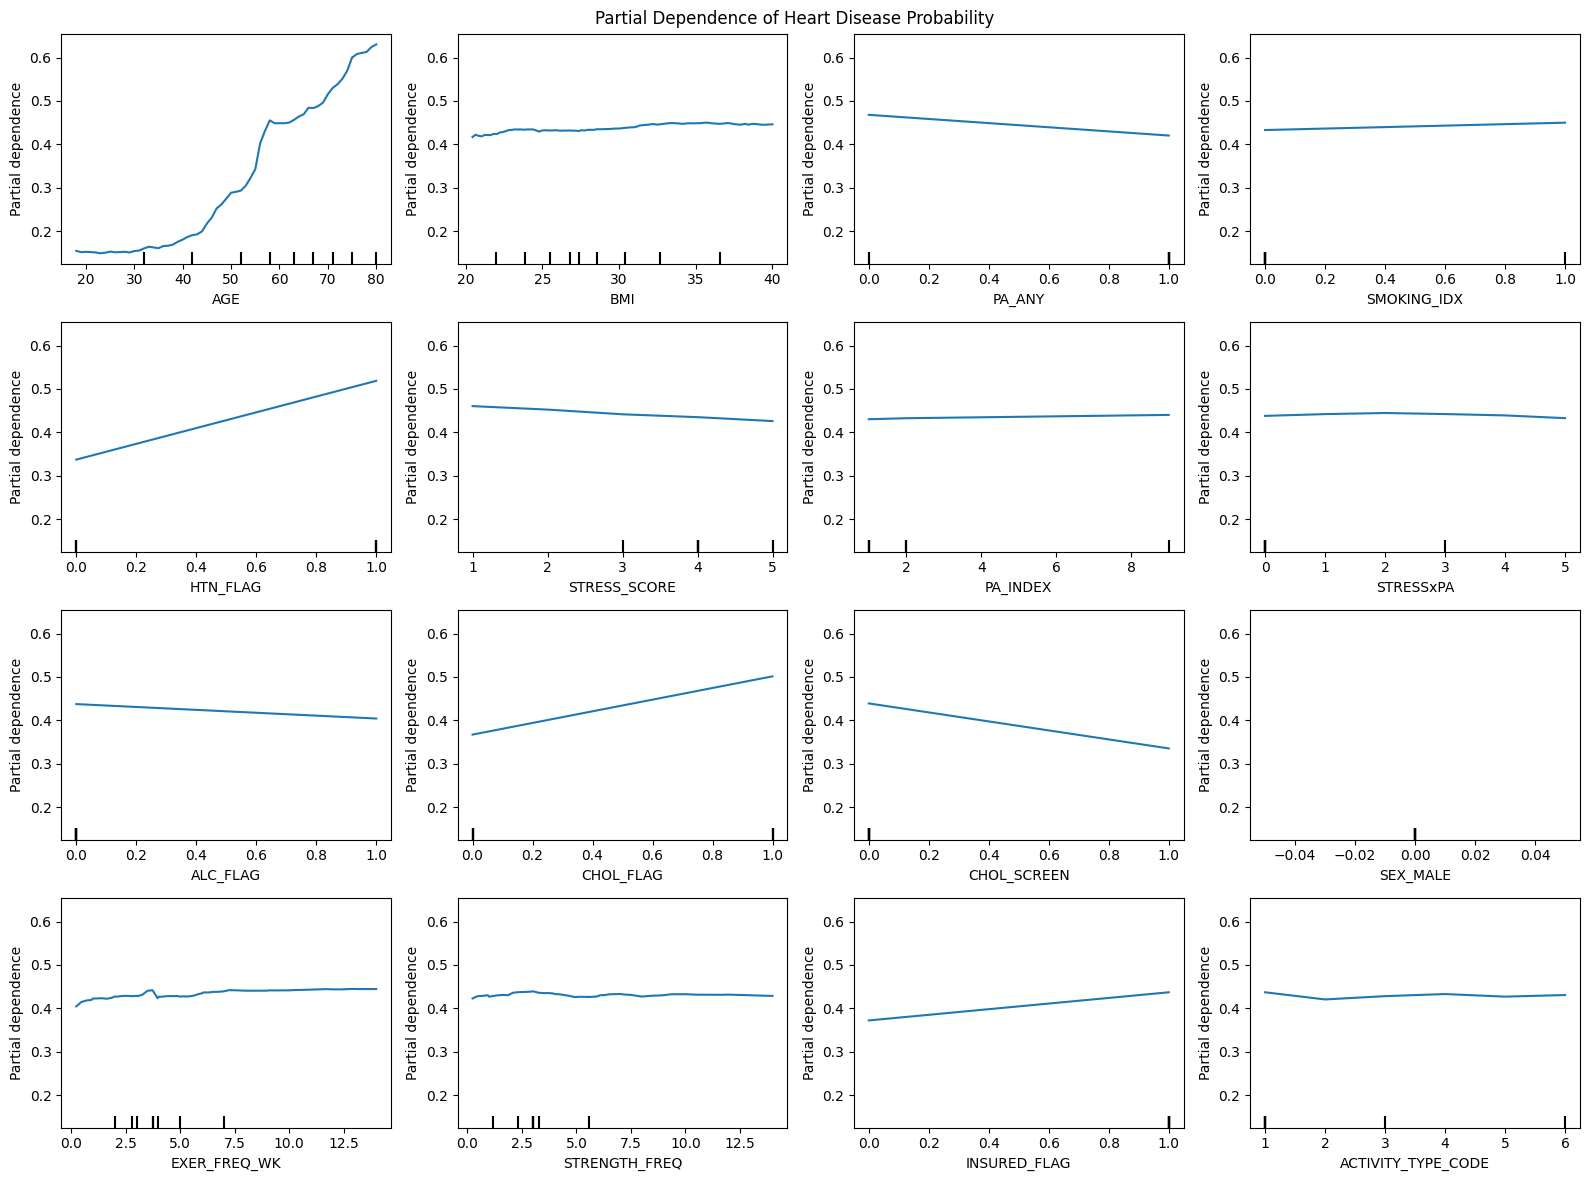

In [ ]:
#Plot ROC
RocCurveDisplay.from_predictions(yte, prob)
plt.title("ROC Curve — Heart Disease Model")
plt.show()

#10-Partial Dependence Plots
plot1=numF
length1=len(plot1)
numCols=4
numRows=int(np.ceil(length1/numCols))

fig,ax=plt.subplots(numRows, numCols, figsize=(4*numCols,3*numRows))
ax=ax.flatten()

ax=ax[:length1]

PartialDependenceDisplay.from_estimator(clf,X,plot1,ax=ax)
plt.suptitle("Partial Dependence of Heart Disease Probability",fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as ort
import numpy as np
import joblib

def export_and_test_onnx(clf,X,numF):
    #save sklearn model
    joblib.dump(clf,"../models/model_heartrisk.joblib")
    print("Saved sklearn model as model_heartrisk.joblib")

    #define input
    X_input=FloatTensorType([None,len(numF)])

    #convert to ONNX
    sample=X.iloc[:1]
    sample=sample.astype(np.float32)

    onnxModel=to_onnx(
        clf,
        sample,
        options={id(clf.named_steps["rf"]):{"zipmap":False}},
        target_opset=15
    )

    path="../models/brfss_heart.onnx"
    f=open(path,"wb")
    f.write(onnxModel.SerializeToString())
    f.close()

    print("Exported ONNX model to:",path)

    #validation
    testDf=X.iloc[:3]
    sk=clf.predict_proba(testDf)[:,1]

    sess=ort.InferenceSession(path)

    inp={}
    cols=list(testDf.columns)
    for i in range(len(cols)):
        c=cols[i]
        v=testDf[c].to_numpy()
        inp[c]=v.reshape(-1,1).astype(np.float32)

    out=sess.run(None,inp)
    onx=out[1][:,1]

    for i in range(len(sk)):
        print(
            f"Sample{i+1}:sklearn={sk[i]:.4f},onnx={onx[i]:.4f},Δ={(onx[i]-sk[i]):+.4f}"
        )

    print("ONNX export verified!")


export_and_test_onnx(clf,X,numF)

💾 Saved sklearn model as model_heartrisk.joblib
✅ Exported ONNX model with preprocessing → ../models/brfss_heart.onnx
Sample 1: sklearn=0.6611, onnx=0.6611, Δ=-0.0000
Sample 2: sklearn=0.7322, onnx=0.7322, Δ=-0.0000
Sample 3: sklearn=0.7855, onnx=0.7855, Δ=-0.0000
✅ ONNX export verified — preprocessing included successfully!




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


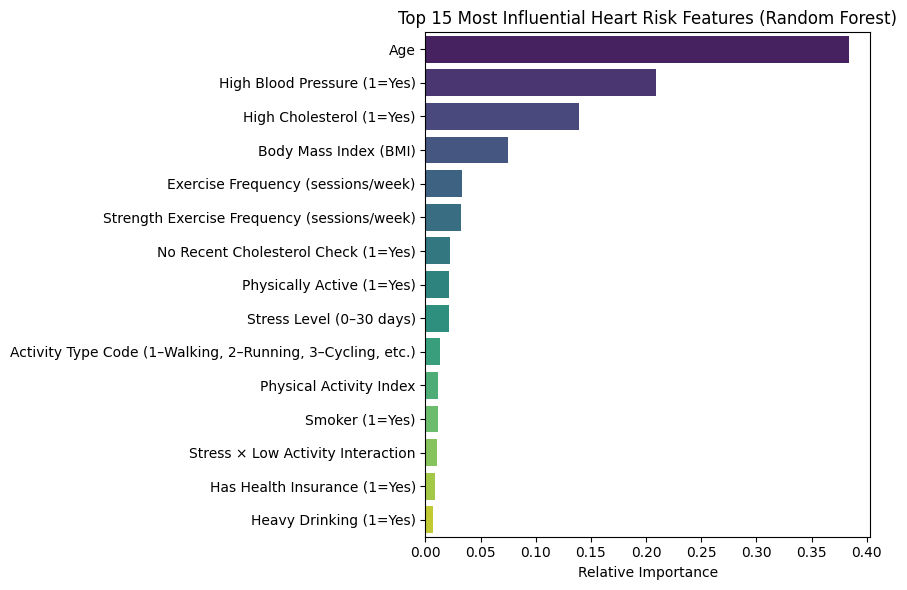


🔹 Top Ranked Heart Disease Risk Predictors:
 1. Age                                           (0.3841)
 2. High Blood Pressure (1=Yes)                   (0.2093)
 3. High Cholesterol (1=Yes)                      (0.1395)
 4. Body Mass Index (BMI)                         (0.0749)
 5. Exercise Frequency (sessions/week)            (0.0333)
 6. Strength Exercise Frequency (sessions/week)   (0.0323)
 7. No Recent Cholesterol Check (1=Yes)           (0.0223)
 8. Physically Active (1=Yes)                     (0.0217)
 9. Stress Level (0–30 days)                      (0.0212)
10. Activity Type Code (1–Walking, 2–Running, 3–Cycling, etc.) (0.0135)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf=clf.named_steps["rf"]
preproc=clf.named_steps["preproc"]

featureNames=preproc.get_feature_names_out()

importances=pd.Series(rf.feature_importances_,index=featureNames)
importances=importances.sort_values(ascending=False)

#Updated labels
labels={
    "num__AGE": "Age",
    "num__BMI": "Body Mass Index (BMI)",
    "num__PA_ANY": "Physically Active (1=Yes)",
    "num__SMOKING_IDX": "Smoker (1=Yes)",
    "num__HTN_FLAG": "High Blood Pressure (1=Yes)",
    "num__STRESS_SCORE": "Stress Level (0–30 days)",
    "num__PA_INDEX": "Physical Activity Index",
    "num__STRESSxPA": "Stress × Low Activity Interaction",
    "num__ALC_FLAG": "Heavy Drinking (1=Yes)",
    "num__CHOL_FLAG": "High Cholesterol (1=Yes)",
    "num__CHOL_SCREEN": "No Recent Cholesterol Check (1=Yes)",
    "num__EXER_FREQ_WK": "Exercise Frequency (sessions/week)",
    "num__STRENGTH_FREQ": "Strength Exercise Frequency (sessions/week)",
    "num__INSURED_FLAG": "Has Health Insurance (1=Yes)",
    "num__ACTIVITY_TYPE_CODE": "Activity Type Code (1–Walking, 2–Running, 3–Cycling, etc.)",
    "num__SEX_MALE": "Sex (1=Male, 0=Female)",
}

df1=pd.DataFrame({
    "Feature": importances.index,
    "Importance": importances.values,
    "Readable": [labels.get(f, f) for f in importances.index]
})

plt.figure(figsize=(9,6))
sns.barplot(
    data=df1.head(15),
    y="Readable", x="Importance", palette="viridis"
)
plt.title(f"Top {15} Most Influential Heart Risk Features (Random Forest)")
plt.xlabel("Relative Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\nTop Ranked Heart Disease Risk Predictors:")
for rank,row in enumerate(df1.head(10).itertuples(), start=1):
    print(f"{rank:>2}. {row.Readable:<45} ({row.Importance:.4f})")

In [ ]:
import json
from pathlib import Path

if "df1" not in locals(): raise ValueError("'df1' not found. Please run the feature importance cell first.")

df1["Percent"] = (
    100*df1["Importance"]/df1["Importance"].sum()
).round(2)

#Keep top 15 relevant columns
df2=df1[["Readable", "Percent"]].head(15).copy()

exportData=[
    {"feature": str(row["Readable"]), "importance_percent": float(row["Percent"])}
    for _, row in df2.iterrows()
]

dir=Path("../models")
dir.mkdir(parents=True, exist_ok=True)
jsonFile=dir/"heart_risk_feature_importance.json"

#Save to JSON
with open(jsonFile, "w", encoding="utf-8") as f: json.dump(exportData, f, indent=2, ensure_ascii=False)

print("Saved feature importances to {jsonFile.resolve()}")
print("\nSample output preview:")
print(json.dumps(exportData[:5], indent=2))


✅ Saved feature importances to models\heart_risk_feature_importance.json

Sample output preview:
[
  {
    "feature": "Age",
    "importance_percent": 38.41
  },
  {
    "feature": "High Blood Pressure (1=Yes)",
    "importance_percent": 20.93
  },
  {
    "feature": "High Cholesterol (1=Yes)",
    "importance_percent": 13.95
  },
  {
    "feature": "Body Mass Index (BMI)",
    "importance_percent": 7.49
  },
  {
    "feature": "Exercise Frequency (sessions/week)",
    "importance_percent": 3.33
  }
]


In [ ]:
import pandas as pd
import numpy as np
import onnxruntime as ort

input=[
    {
        "AGE": 30, "BMI": 16.1, "PA_ANY": 1, "SMOKING_IDX": 0, "HTN_FLAG": 0,
        "STRESS_SCORE": 0, "PA_INDEX": 1, "STRESSxPA": 0,
        "ALC_FLAG": 0, "CHOL_FLAG": 0, "CHOL_SCREEN": 0,
        "EXER_FREQ_WK": 0, "STRENGTH_FREQ": 0, "INSURED_FLAG": 1,
        "ACTIVITY_TYPE_CODE": 1, 
        "SEX_MALE": 1
    },
    {
        "AGE": 35, "BMI": 16.1, "PA_ANY": 1, "SMOKING_IDX": 0, "HTN_FLAG": 0,
        "STRESS_SCORE": 0, "PA_INDEX": 1, "STRESSxPA": 0,
        "ALC_FLAG": 0, "CHOL_FLAG": 0, "CHOL_SCREEN": 0,
        "EXER_FREQ_WK": 0, "STRENGTH_FREQ": 0, "INSURED_FLAG": 1,
        "ACTIVITY_TYPE_CODE": 1,
        "SEX_MALE": 1
    },
    {
        "AGE": 40, "BMI": 16.1, "PA_ANY": 1, "SMOKING_IDX": 0, "HTN_FLAG": 0,
        "STRESS_SCORE": 0, "PA_INDEX": 1, "STRESSxPA": 0,
        "ALC_FLAG": 0, "CHOL_FLAG": 0, "CHOL_SCREEN": 0,
        "EXER_FREQ_WK": 0, "STRENGTH_FREQ": 0, "INSURED_FLAG": 1,
        "ACTIVITY_TYPE_CODE": 1, 
        "SEX_MALE": 1
    }
]

testDf=pd.DataFrame(input)

onnxPath="../models/brfss_heart.onnx"
sess=ort.InferenceSession(onnxPath)

inputs={col: testDf[col].to_numpy(np.float32).reshape(-1, 1)
              for col in testDf.columns}

# execute inference
labels,probs=sess.run(None, inputs)

for i, p in enumerate(probs[:, 1]):
    print(f"Case {i+1} → Probability of Heart Disease: {p:.3f}")


Case 1 → Probability of Heart Disease: 0.153
Case 2 → Probability of Heart Disease: 0.162
Case 3 → Probability of Heart Disease: 0.197
